In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv(r"E:\coding\ML\Tech_Tensor\Credit_card_fraud\credit_card_fraud\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

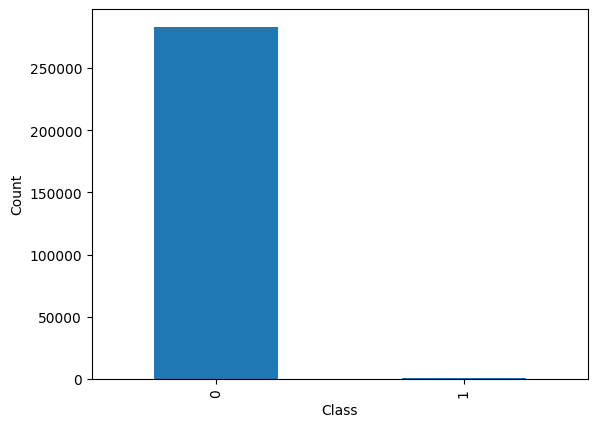

In [11]:
df["Class"].value_counts().plot(kind="bar")
plt.xticks()
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

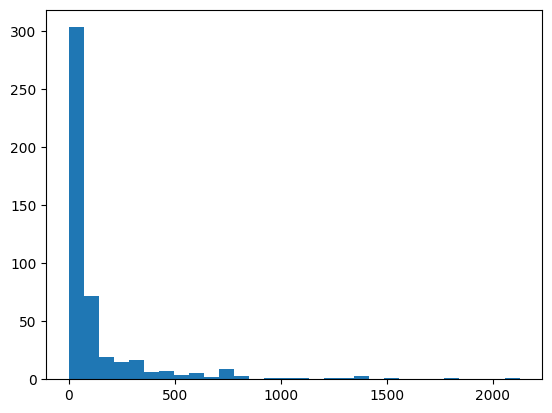

In [12]:
fraud = df[df["Class"]==1]
plt.hist(fraud["Amount"], bins=30)
plt.show()

In [15]:
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

In [28]:
X= df.drop("Class", axis=1)
Y= df["Class"]

In [29]:
x_train,  x_test, y_train, y_test= train_test_split(X,Y, test_size=0.2,random_state=42, stratify=Y)

In [30]:
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_ratio = negative_cases / positive_cases

In [31]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
RFC = RandomForestClassifier(class_weight="balanced")
XGBC = XGBClassifier(scale_pos_weight=scale_ratio, random_state=42)

In [32]:
RFC.fit(x_train,y_train)
XGBC.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [33]:
y_pred_RFC = RFC.predict(x_test)
y_pred_XGBC = XGBC.predict(x_test)

In [34]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

In [35]:
#for random forest
rf_accuracy = accuracy_score(y_test , y_pred_RFC)
rf_precision = precision_score(y_test , y_pred_RFC)
rf_recall = recall_score(y_test , y_pred_RFC)
rf_f1 = f1_score(y_test , y_pred_RFC)
rf_confusionMatrix = confusion_matrix(y_test , y_pred_RFC)

#for XG boost
xgb_accuracy = accuracy_score(y_test ,y_pred_XGBC)
xgb_precision = precision_score(y_test ,y_pred_XGBC)
xgb_recall = recall_score(y_test ,y_pred_XGBC)
xgb_f1 = f1_score(y_test ,y_pred_XGBC)
xgb_confusionMatrix = confusion_matrix(y_test ,y_pred_XGBC)

In [36]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Random Forest': [rf_accuracy,rf_precision,rf_recall,rf_f1],
    'XGBoost': [xgb_accuracy,xgb_precision,xgb_recall,xgb_f1]
})

comparison

,Metric,Random Forest,XGBoost
0,Accuracy,0.999471,0.999595
1,Precision,0.985075,0.973684
2,Recall,0.694737,0.778947
3,F1 Score,0.814815,0.865497


In [37]:
import pickle
fh=open('credit_card_fraud.pkl', 'wb')
pickle.dump(XGBC,fh)
fh.close()